In [1]:
# Install and import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Configure visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

print("Environment successfully initialized.")

Environment successfully initialized.


In [4]:
# Upload datasets directly or load from local/Google Drive environment
# Required files: 'ab_data.csv' and 'countries.csv'

# Load A/B testing data and country mappings
df_ab = pd.read_csv('ab_data.csv')
df_countries = pd.read_csv('countries.csv')

print("--- A/B Data Info ---")
print(df_ab.info())
print("\nFirst 5 rows of A/B Data:")
print(df_ab.head())

print("\n--- Country Data Info ---")
print(df_countries.info())
print("\nFirst 5 rows of Country Data:")
print(df_countries.head())

--- A/B Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB
None

First 5 rows of A/B Data:
   user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1

--- Country Data Info ---
<class 'panda

In [5]:
# 1. Identify and filter out mismatch rows where group and landing_page do not align
# Control group should see 'old_page', Treatment group should see 'new_page'
mismatches = df_ab[
    ((df_ab['group'] == 'control') & (df_ab['landing_page'] != 'old_page')) |
    ((df_ab['group'] == 'treatment') & (df_ab['landing_page'] != 'new_page'))
]
print(f"Removed mismatch rows: {len(mismatches)}")

df_clean = df_ab.drop(mismatches.index)

# 2. Deduplicate user IDs (keep the first recorded session per user)
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['user_id'], keep='first')
print(f"Removed duplicate user records: {initial_rows - len(df_clean)}")

# 3. Merge clean dataset with country information
df_merged = df_clean.merge(df_countries, on='user_id', how='inner')
print(f"Final cleaned dataset size: {len(df_merged)} rows")

# Verify final sample sizes by group
sample_sizes = df_merged.groupby('group').agg(
    Users=('converted', 'count'),
    Conversions=('converted', 'sum')
).reset_index()
print("\nSample Sizes After Cleaning:")
print(sample_sizes)

Removed mismatch rows: 3893
Removed duplicate user records: 1
Final cleaned dataset size: 290584 rows

Sample Sizes After Cleaning:
       group   Users  Conversions
0    control  145274        17489
1  treatment  145310        17264


Conversion Summary:
       group   count      mean       std     cr_pct
0    control  145274  0.120386  0.325414  12.038630
1  treatment  145310  0.118808  0.323564  11.880807


/tmp/ipykernel_5111/1361399710.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=sample_sizes, x='group', y='Users', palette=['#4c6ef5', '#fa8c16'])


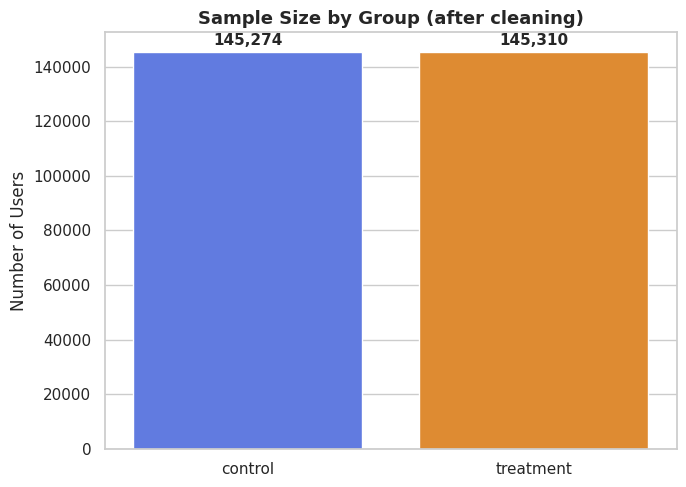

/tmp/ipykernel_5111/1361399710.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax2 = sns.barplot(
/tmp/ipykernel_5111/1361399710.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(
/tmp/ipykernel_5111/1361399710.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f'{int(x*100)}' for x in plt.gca().get_yticks()])


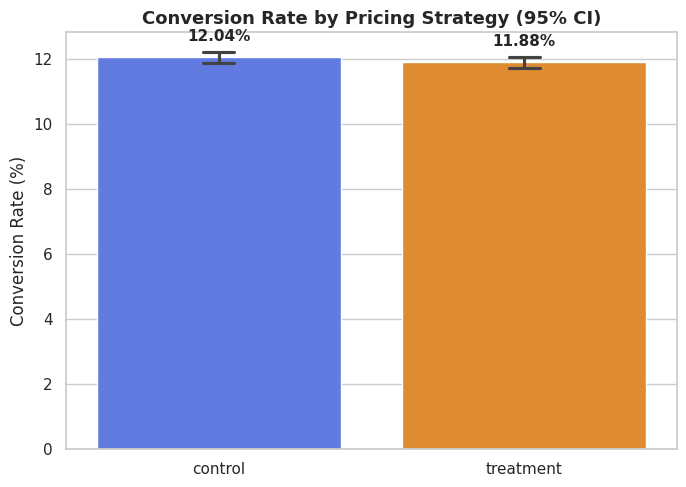

In [6]:
# Calculate conversion stats
conversion_summary = df_merged.groupby('group')['converted'].agg(['count', 'mean', 'std']).reset_index()
conversion_summary['cr_pct'] = conversion_summary['mean'] * 100
print("Conversion Summary:")
print(conversion_summary)

# Figure 1: Sample Size by Group
plt.figure(figsize=(7, 5))
ax1 = sns.barplot(data=sample_sizes, x='group', y='Users', palette=['#4c6ef5', '#fa8c16'])
plt.title("Sample Size by Group (after cleaning)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Users")
plt.xlabel("")
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 2: Conversion Rate by Pricing Strategy with 95% Confidence Intervals
plt.figure(figsize=(7, 5))
ax2 = sns.barplot(
    data=df_merged, x='group', y='converted', ci=95, capsize=0.1, palette=['#4c6ef5', '#fa8c16']
)
plt.title("Conversion Rate by Pricing Strategy (95% CI)", fontsize=13, fontweight='bold')
plt.ylabel("Conversion Rate (%)")
plt.xlabel("")
plt.gca().set_yticklabels([f'{int(x*100)}' for x in plt.gca().get_yticks()])

# Annotate exact percentages
cr_control = conversion_summary.loc[conversion_summary['group']=='control', 'cr_pct'].values[0]
cr_treatment = conversion_summary.loc[conversion_summary['group']=='treatment', 'cr_pct'].values[0]
ax2.text(0, cr_control/100 + 0.005, f"{cr_control:.2f}%", ha='center', fontweight='bold')
ax2.text(1, cr_treatment/100 + 0.005, f"{cr_treatment:.2f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# Extract conversion arrays for both groups
control_conv = df_merged[df_merged['group'] == 'control']['converted']
treatment_conv = df_merged[df_merged['group'] == 'treatment']['converted']

# Perform Welch's t-test (equal_var=False)
t_stat, p_val_ttest = stats.ttest_ind(treatment_conv, control_conv, equal_var=False)

# Compute 95% Confidence Interval for the mean difference
diff_mean = treatment_conv.mean() - control_conv.mean()
se_diff = np.sqrt((control_conv.var() / len(control_conv)) + (treatment_conv.var() / len(treatment_conv)))
ci_low = diff_mean - 1.96 * se_diff
ci_high = diff_mean + 1.96 * se_diff

print("=== Test 1: Welch's Independent t-test Results ===")
print(f"Control Mean Conversion   : {control_conv.mean()*100:.3f}%")
print(f"Treatment Mean Conversion : {treatment_conv.mean()*100:.3f}%")
print(f"Difference (Trt - Ctrl)   : {diff_mean*100:.3f} pp")
print(f"95% CI of Difference       : [{ci_low*100:.3f}%, {ci_high*100:.3f}%]")
print(f"t-statistic                : {t_stat:.3f}")
print(f"p-value                    : {p_val_ttest:.3f}")

if p_val_ttest < 0.05:
    print("Verdict: Reject Null Hypothesis (Statistically Significant Difference)")
else:
    print("Verdict: Fail to Reject Null Hypothesis (No Statistically Significant Difference)")

=== Test 1: Welch's Independent t-test Results ===
Control Mean Conversion   : 12.039%
Treatment Mean Conversion : 11.881%
Difference (Trt - Ctrl)   : -0.158 pp
95% CI of Difference       : [-0.394%, 0.078%]
t-statistic                : -1.311
p-value                    : 0.190
Verdict: Fail to Reject Null Hypothesis (No Statistically Significant Difference)


In [8]:
# Construct 2x2 contingency table (group vs. converted)
contingency_table = pd.crosstab(df_merged['group'], df_merged['converted'])
contingency_table.columns = ['Not Converted', 'Converted']

print("--- Contingency Table ---")
print(contingency_table)

# Run Chi-Square test
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table, correction=False)

print("\n=== Test 2: Chi-Square Test Results ===")
print(f"Chi-square Statistic : {chi2_stat:.3f}")
print(f"Degrees of Freedom   : {dof}")
print(f"p-value              : {p_val_chi2:.3f}")

if p_val_chi2 < 0.05:
    print("Verdict: Reject Null Hypothesis (Strategy and Conversion are Related)")
else:
    print("Verdict: Fail to Reject Null Hypothesis (Strategy and Conversion are Independent)")

--- Contingency Table ---
           Not Converted  Converted
group                              
control           127785      17489
treatment         128046      17264

=== Test 2: Chi-Square Test Results ===
Chi-square Statistic : 1.719
Degrees of Freedom   : 1
p-value              : 0.190
Verdict: Fail to Reject Null Hypothesis (Strategy and Conversion are Independent)


=== Test 3: One-Way ANOVA Results ===
Across 3 Countries            : F-stat = 1.605, p-value = 0.201
Across 6 Country-Strategy Groups: F-stat = 1.466, p-value = 0.197


/tmp/ipykernel_5111/1604716073.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax3 = sns.barplot(
/tmp/ipykernel_5111/1604716073.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f'{int(x*100)}' for x in plt.gca().get_yticks()])


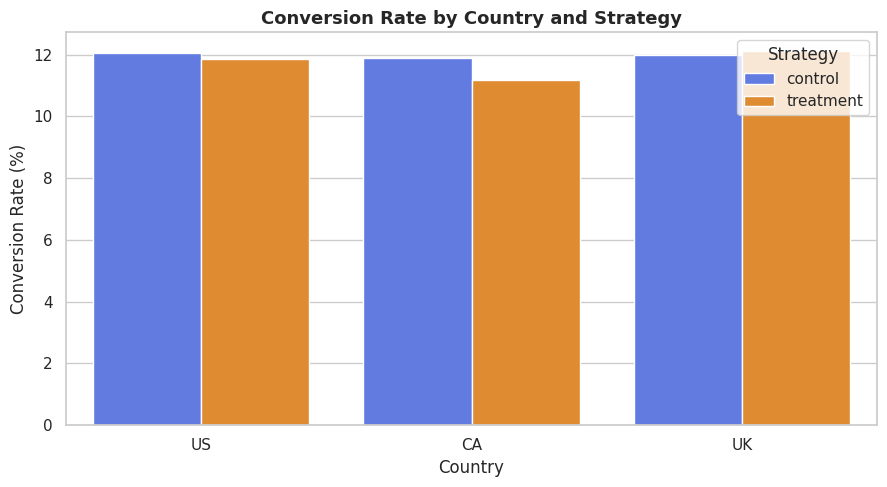

In [9]:
# 1. ANOVA across the 3 countries
ca_conv = df_merged[df_merged['country'] == 'CA']['converted']
uk_conv = df_merged[df_merged['country'] == 'UK']['converted']
us_conv = df_merged[df_merged['country'] == 'US']['converted']

f_stat_country, p_val_country = stats.f_oneway(ca_conv, uk_conv, us_conv)

# 2. ANOVA across 6 Country/Strategy combinations
df_merged['group_country'] = df_merged['group'] + "_" + df_merged['country']
group_series = [group['converted'].values for _, group in df_merged.groupby('group_country')]

f_stat_combo, p_val_combo = stats.f_oneway(*group_series)

print("=== Test 3: One-Way ANOVA Results ===")
print(f"Across 3 Countries            : F-stat = {f_stat_country:.3f}, p-value = {p_val_country:.3f}")
print(f"Across 6 Country-Strategy Groups: F-stat = {f_stat_combo:.3f}, p-value = {p_val_combo:.3f}")

# Figure 3: Visualization of Conversion Rate by Country and Strategy
plt.figure(figsize=(9, 5))
ax3 = sns.barplot(
    data=df_merged, x='country', y='converted', hue='group',
    ci=None, palette=['#4c6ef5', '#fa8c16']
)
plt.title("Conversion Rate by Country and Strategy", fontsize=13, fontweight='bold')
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Country")
plt.legend(title="Strategy")
plt.gca().set_yticklabels([f'{int(x*100)}' for x in plt.gca().get_yticks()])
plt.tight_layout()
plt.show()